In [1]:
import numpy as np
import pandas as pd

In [2]:
# Load diabetes dataset
df = pd.read_csv(r"C:\Users\omgow\OneDrive\Desktop\MSIS\AML_LAB\project_LAB_4\data\diabetes.csv")

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
df.shape

(768, 9)

In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [8]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
# Check missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
# Check duplicate rows
df.duplicated().sum()

0

In [12]:
# Check target distribution
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [13]:
# Check target percentages
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [14]:
# Replace invalid zeros with NaN
cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[cols] = df[cols].replace(0, np.nan)

In [15]:
# Check missing values after cleaning
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [16]:
# Import imputer
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

In [17]:
# Separate input and target
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [18]:
# Check shapes
print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (768, 8)
Y shape: (768,)


In [37]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=45,
    stratify=y
)

In [38]:
# Fill missing values using training mean
imputer = SimpleImputer(strategy="mean")

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [39]:
# Check missing values after imputation
print("Training missing values:", np.isnan(x_train).sum())
print("Testing missing values:", np.isnan(x_test).sum())

Training missing values: 0
Testing missing values: 0


In [40]:
from sklearn.preprocessing import StandardScaler

sc_x = StandardScaler()

x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

In [41]:
# Create Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

In [42]:
# Train the model
classifier.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [43]:
# Predict test data
y_pred = classifier.predict(x_test)

y_pred

array([1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1], dtype=int64)

In [44]:
# Compare actual and predicted values
print("Actual:", y_test)
print("Predicted:", y_pred)

Actual: [1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1
 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0
 1 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0
 1 1 0 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0
 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0]
Predicted: [1 0 1 0 1 0 0 1 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 1 1 0 1 1 0 0 0 0 0 1 1 0 1
 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0 1 1 1 0 0 0
 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 1 1 0 0 0 0 1 0
 0 0 1 0 0 0 1]


In [45]:
# Calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7395833333333334


In [46]:
# Display confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[100  25]
 [ 25  42]]


In [47]:
# Display classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80       125
           1       0.63      0.63      0.63        67

    accuracy                           0.74       192
   macro avg       0.71      0.71      0.71       192
weighted avg       0.74      0.74      0.74       192



[Text(0.47650462962962964, 0.975, 'x[1] <= 0.159\nentropy = 0.933\nsamples = 576\nvalue = [375, 201]'),
 Text(0.19907407407407407, 0.925, 'x[7] <= -0.395\nentropy = 0.719\nsamples = 363\nvalue = [291, 72]'),
 Text(0.1037037037037037, 0.875, 'x[5] <= 1.907\nentropy = 0.415\nsamples = 203\nvalue = [186, 17]'),
 Text(0.08888888888888889, 0.825, 'x[5] <= -0.183\nentropy = 0.366\nsamples = 200\nvalue = [186.0, 14.0]'),
 Text(0.05925925925925926, 0.775, 'x[0] <= 0.971\nentropy = 0.13\nsamples = 111\nvalue = [109, 2]'),
 Text(0.044444444444444446, 0.725, 'x[4] <= -1.237\nentropy = 0.075\nsamples = 110\nvalue = [109, 1]'),
 Text(0.02962962962962963, 0.675, 'x[6] <= 0.428\nentropy = 0.391\nsamples = 13\nvalue = [12, 1]'),
 Text(0.014814814814814815, 0.625, 'entropy = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.044444444444444446, 0.625, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.05925925925925926, 0.675, 'entropy = 0.0\nsamples = 97\nvalue = [97, 0]'),
 Text(0.07407407407407407, 0

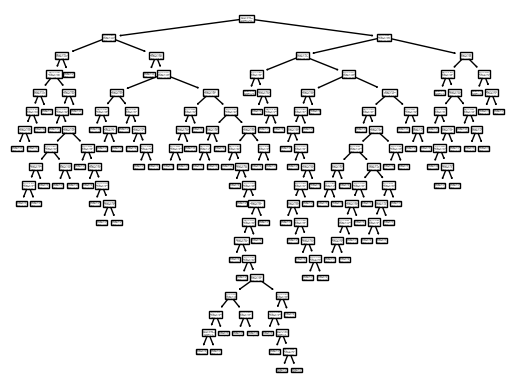

In [48]:
from sklearn import tree
tree.plot_tree(classifier)